# Buscando Diferencias entre Grupos Pareados

## ANOVA de efectos mixtos

### Procedimiento
- Importar librerias
- Cargar la primera hoja de trabajo de excel en Pandas
- Limpiar los datos
- Prueba de Normalidad (SHAPIRO-WILK)
- Prueba de Homocedasticidad (LEVENE)
- Prueba de esfericidad (W de MAUCHLY)
- Prueba ANOVA de mefectos mixtos
- Para la categoria con 3 o mas grupos HSD Tukey

In [15]:
#__ Cargar librerias
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene, tukey_hsd
from pingouin import sphericity, mixed_anova
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
#___ Cargar la hoja de trabajo en un dataframe
anovamx_df = pd.read_excel('datos_analisis_estadistico.xlsx', sheet_name = 'ANOVA MIXTA')
anovamx_df

,PACIENTE,SEXO,ANTES,1 DIA,2 DIAS
0,PACIENTE #01,MASCULINO,126.058932,121.826773,123.903062
1,PACIENTE #02,FEMENINO,143.360773,145.025254,105.256409
2,PACIENTE #03,MASCULINO,126.984877,109.728038,120.739260
3,PACIENTE #04,MASCULINO,128.887336,130.310039,102.423014
4,PACIENTE #05,FEMENINO,126.125814,136.724023,113.388246
...,...,...,...,...,...
95,PACIENTE #96,MASCULINO,121.795130,132.657923,129.934206
96,PACIENTE #97,MASCULINO,130.250554,110.377826,122.270326
97,PACIENTE #98,FEMENINO,114.434271,100.095125,114.110044
98,PACIENTE #99,MASCULINO,128.254270,119.580423,125.268680


In [3]:
#___ PARTE 1
##___ Transformar la forma del dataframe para utilizar el test de normalidad (SHAPIRO-WILK)
###___ Los datos deben estar en formato largo para la prueba anova
melted_anovamx_df = anovamx_df.melt(id_vars=['PACIENTE', 'SEXO'], value_vars=['ANTES', '1 DIA', '2 DIAS'], var_name='TIEMPO', value_name='MEDICION')
melted_anovamx_df

,PACIENTE,SEXO,TIEMPO,MEDICION
0,PACIENTE #01,MASCULINO,ANTES,126.058932
1,PACIENTE #02,FEMENINO,ANTES,143.360773
2,PACIENTE #03,MASCULINO,ANTES,126.984877
3,PACIENTE #04,MASCULINO,ANTES,128.887336
4,PACIENTE #05,FEMENINO,ANTES,126.125814
...,...,...,...,...
295,PACIENTE #96,MASCULINO,2 DIAS,129.934206
296,PACIENTE #97,MASCULINO,2 DIAS,122.270326
297,PACIENTE #98,FEMENINO,2 DIAS,114.110044
298,PACIENTE #99,MASCULINO,2 DIAS,125.268680


In [6]:
#___ Prueba de normalidad METODO A (RESIDUOS)
modelo = smf.mixedlm("MEDICION ~ SEXO", melted_anovamx_df, groups=melted_anovamx_df["PACIENTE"])
modelo_ajustado = modelo.fit()

##___ Se extraen los residuos
residuos = modelo_ajustado.resid

c:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Python311\Lib\site-packages\statsmodels\r

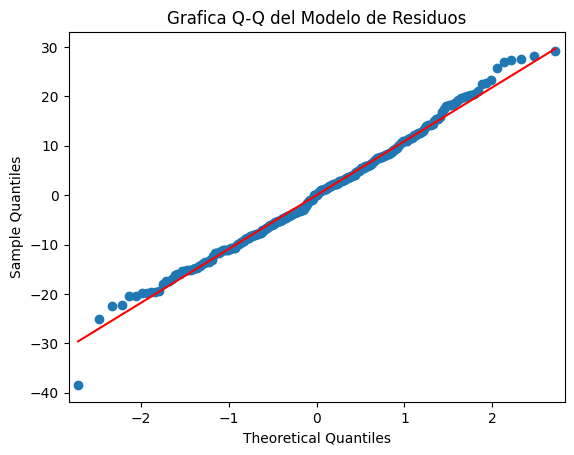

In [9]:
#___ Prueba de normalidad METODO A (VISUAL)
sm.qqplot(residuos, line='s')
plt.title("Grafica Q-Q del Modelo de Residuos")
plt.show()

In [10]:
#___ Prueba de normalidad METODO B (ANALITICA SHAPIRO-WILK)
###___ La funcion sp.shapiro() verifica que una o mas columnas en el dataframe siguen una distribucion normal.
prueba_normalidad_B = shapiro(residuos)
prueba_normalidad_B

ShapiroResult(statistic=0.9935475587844849, pvalue=0.22754062712192535)

In [11]:
#___ Prueba de homocedasticidad
prueba_homos = levene(anovamx_df['ANTES'], anovamx_df['1 DIA'], anovamx_df['2 DIAS'])
prueba_homos

LeveneResult(statistic=0.6659286326491054, pvalue=0.5145616287856141)

In [14]:
#___ Prueba de esfericidad (W de MAUCHLY) FORMATO LARGO
###___ Solo para el factor intra-sujeto
prueba_esfe = sphericity(data=melted_anovamx_df, dv='MEDICION', within='TIEMPO', subject='PACIENTE')
prueba_esfe

SpherResults(spher=True, W=0.9787001785452238, chi2=2.1099337396988123, dof=2, pval=0.3482039631648412)

In [16]:
#___ Prueba de ANOVA de efectos mixtos
prueba_anovamx = mixed_anova(data=melted_anovamx_df, dv='MEDICION', within='TIEMPO', between='SEXO', subject='PACIENTE')
prueba_anovamx

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,SEXO,6.253860,1,98,6.253860,0.064192,8.005192e-01,0.000655,NaN
1,TIEMPO,5871.239677,2,196,2935.619839,29.088460,8.664748e-12,0.228884,0.979144
2,Interaction,502.291073,2,196,251.145536,2.488550,8.565064e-02,0.024765,NaN


In [17]:
#___ Prueba post-hoc Tukey  (Libreria SciPy)
prueba_tukey = tukey_hsd(melted_anovamx_df[melted_anovamx_df['TIEMPO'] == 'ANTES']['MEDICION'], melted_anovamx_df[melted_anovamx_df['TIEMPO'] == '1 DIA']['MEDICION'], melted_anovamx_df[melted_anovamx_df['TIEMPO'] == '2 DIAS']['MEDICION'])
print(prueba_tukey)


Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      6.919     0.000     3.580    10.258
 (0 - 2)     10.682     0.000     7.343    14.021
 (1 - 0)     -6.919     0.000   -10.258    -3.580
 (1 - 2)      3.763     0.023     0.424     7.102
 (2 - 0)    -10.682     0.000   -14.021    -7.343
 (2 - 1)     -3.763     0.023    -7.102    -0.424



Text(0.5, 1.0, 'FUNCIONAMIENTO MEDICAMENTO')

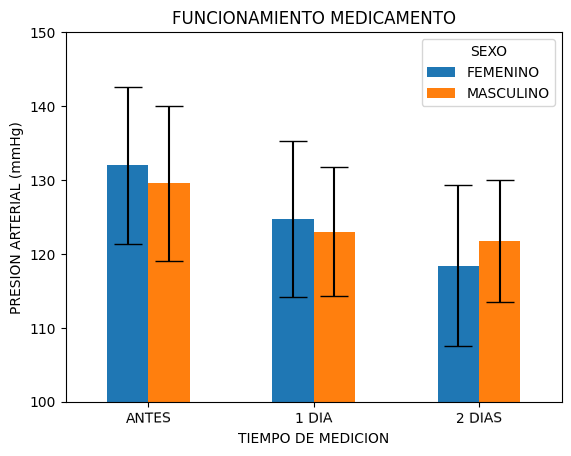

In [19]:
#___ Grafica de error promedio
##___ Prepararr el dataframe
promedio_sexo = anovamx_df[['SEXO','ANTES','1 DIA', '2 DIAS']].groupby('SEXO').mean()
destd_sexo = anovamx_df[['SEXO','ANTES','1 DIA', '2 DIAS']].groupby('SEXO').std()

promedio_sexo_t = promedio_sexo.transpose()
destd_sexo_t = destd_sexo.transpose()

promedio_sexo_t.plot(kind='bar', yerr=destd_sexo_t, capsize=10, ylim=(100,150), rot=1)
plt.xlabel('TIEMPO DE MEDICION')
plt.ylabel('PRESION ARTERIAL (mmHg)')
plt.title('FUNCIONAMIENTO MEDICAMENTO')